Every model is like predicting random stuff

In [1]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
# Import everything for Random Forest
from sklearn.ensemble import RandomForestRegressor
# K-Fold Cross Validation
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS

In [4]:
df = pd.read_csv(PATHS['processed_data'] / 'missing_values_imputation.csv')
df.head()

,name,x,y,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
0,santa ana,41.882506,0.580850,ebro,rio noguera ribagorcana,NaN,NaN,NaN,huesca,aragon,presa fabrica arco gravedad,380.30,99.6,https://sig.mapama.gob.es/WebServices/clientew...
1,tanes,43.220950,-5.427761,cantabrico occidental,rio nalon,NaN,NaN,NaN,asturias,principado asturias,presa fabrica gravedad (hormigon vibrado),495.00,95.0,https://sig.mapama.gob.es/WebServices/clientew...
2,val,41.875792,-1.786973,ebro,rio casa o val,NaN,NaN,https://www.wikidata.org/wiki/Q95570755,zaragoza,aragon,presa fabrica gravedad (hormigon compactado),629.15,94.4,https://sig.mapama.gob.es/WebServices/clientew...
3,peares,42.465137,-7.723744,mino sil,rio mino,https://www.google.com/search?kgmid=/g/155svy9k,NaN,https://www.wikidata.org/wiki/Q11986800,lugo,galicia,presa fabrica gravedad (hormigon vibrado),196.50,94.0,https://sig.mapama.gob.es/WebServices/clientew...
4,mediano,42.313617,0.210738,ebro,rio cinca,https://www.google.com/search?kgmid=/g/121bdb0g,https://www.openstreetmap.org/relation/7141904,https://www.wikidata.org/wiki/Q3215482,huesca,aragon,presa fabrica gravedad (hormigon vibrado),529.50,92.0,https://sig.mapama.gob.es/WebServices/clientew...


In [9]:
# Prepare data with the simplest model
df_dropped = df[['x', 'y', 'crest_elevation', 'dam_height']]
training_data = df_dropped[df_dropped['dam_height'].notna()]
testing_data = df_dropped[df_dropped['dam_height'].isna()]
X = training_data.drop(columns=['dam_height'])
y = training_data['dam_height']
X.head()

,x,y,crest_elevation
0,41.882506,0.580850,380.30
1,43.220950,-5.427761,495.00
2,41.875792,-1.786973,629.15
3,42.465137,-7.723744,196.50
4,42.313617,0.210738,529.50


In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=27)
rmse_scores = []
mae_scores = []
r2_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    model = RandomForestRegressor(random_state=27)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

print(f"Average RMSE: {np.mean(rmse_scores):.3f}")
print(f"Average MAE: {np.mean(mae_scores):.3f}")
print(f"Average R2: {np.mean(r2_scores):.3f}")

Average RMSE: 28.090
Average MAE: 22.264
Average R2: 0.082


In [42]:
# Smoothed target encoding for categorical columns (leakage-free, with all fold predictions)
df_dropped = df.drop(columns=['name', 'google', 'openstreetmap', 'wikidata', 'report'])
training_data = df_dropped[df_dropped['dam_height'].notna()]
testing_data = df_dropped[df_dropped['dam_height'].isna()]
X = training_data.drop(columns=['dam_height'])
y = training_data['dam_height']

def smoothed_target_encoding(train_df, target_col, categorical_cols, smoothing=10):
    df_encoded = train_df.copy()
    global_mean = train_df[target_col].mean()
    for col in categorical_cols:
        agg = train_df.groupby(col)[target_col].agg(['mean', 'count'])
        smoothing_factor = 1 / (1 + np.exp(-(agg['count'] - smoothing)))
        smooth = global_mean * (1 - smoothing_factor) + agg['mean'] * smoothing_factor
        df_encoded[col + '_te'] = train_df[col].map(smooth)
    return df_encoded

categorical_cols = [col for col in X.columns if X[col].dtype == 'object']

kf = KFold(n_splits=5, shuffle=True, random_state=27)
rmse_scores = []
mae_scores = []
r2_scores = []
all_y_true = []
all_y_pred = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    if categorical_cols:
        # Fit encoder only on training fold, apply to both train and val
        train_df = X_train.copy()
        train_df['dam_height'] = y_train.values
        X_train_enc = smoothed_target_encoding(train_df, 'dam_height', categorical_cols)
        X_train_model = X_train_enc.drop(columns=categorical_cols + ['dam_height'])

        # For validation, use mapping from train
        global_mean = y_train.mean()
        X_val_enc = X_val.copy()
        for col in categorical_cols:
            agg = y_train.groupby(X_train[col]).agg(['mean', 'count'])
            smoothing_factor = 1 / (1 + np.exp(-(agg['count'] - 10)))
            smooth = global_mean * (1 - smoothing_factor) + agg['mean'] * smoothing_factor
            X_val_enc[col + '_te'] = X_val[col].map(smooth)
        X_val_model = X_val_enc.drop(columns=categorical_cols)
    else:
        X_train_model = X_train.copy()
        X_val_model = X_val.copy()

    model = RandomForestRegressor(random_state=27)
    model.fit(X_train_model, y_train)
    y_pred = model.predict(X_val_model)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)

print(f"[Smoothed Target Encoding, leakage-free] Average RMSE: {np.mean(rmse_scores):.3f}")
print(f"[Smoothed Target Encoding, leakage-free] Average MAE: {np.mean(mae_scores):.3f}")
print(f"[Smoothed Target Encoding, leakage-free] Average R2: {np.mean(r2_scores):.3f}")

# Show DataFrame of true vs predicted values for all folds
results_df = pd.DataFrame({'True': all_y_true, 'Predicted': all_y_pred})
display(results_df)

[Smoothed Target Encoding, leakage-free] Average RMSE: 29.744
[Smoothed Target Encoding, leakage-free] Average MAE: 23.831
[Smoothed Target Encoding, leakage-free] Average R2: -0.024


,True,Predicted
0,89.0,47.6390
1,86.0,53.7675
2,80.5,38.5648
3,8.3,50.4401
4,79.6,89.6870
...,...,...
154,35.0,36.9220
155,31.0,35.2368
156,18.0,40.0112
157,141.0,44.9824


# OVERFITTING THE NEXT ONE

In [41]:
# Plain target encoding (no smoothing) for categorical columns

def plain_target_encoding(train_df, target_col, categorical_cols):
    df_encoded = train_df.copy()
    for col in categorical_cols:
        means = train_df.groupby(col)[target_col].mean()
        df_encoded[col + '_te'] = train_df[col].map(means)
    return df_encoded

categorical_cols = [col for col in X.columns if X[col].dtype == 'object']

kf = KFold(n_splits=5, shuffle=True, random_state=27)
rmse_scores = []
mae_scores = []
r2_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    if categorical_cols:
        # Fit encoder only on training fold, apply to both train and val
        train_df = X_train.copy()
        train_df['dam_height'] = y_train.values
        X_train_enc = plain_target_encoding(train_df, 'dam_height', categorical_cols)
        X_train_model = X_train_enc.drop(columns=categorical_cols + ['dam_height'])

        # For validation, use mapping from train
        X_val_enc = X_val.copy()
        for col in categorical_cols:
            means = y_train.groupby(X_train[col]).mean()
            X_val_enc[col + '_te'] = X_val[col].map(means)
        X_val_model = X_val_enc.drop(columns=categorical_cols)
    else:
        X_train_model = X_train.copy()
        X_val_model = X_val.copy()

    model = RandomForestRegressor(random_state=27)
    model.fit(X_train_model, y_train)
    y_pred = model.predict(X_val_model)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

print(f"[Plain Target Encoding, leakage-free] Average RMSE: {np.mean(rmse_scores):.3f}")
print(f"[Plain Target Encoding, leakage-free] Average MAE: {np.mean(mae_scores):.3f}")
print(f"[Plain Target Encoding, leakage-free] Average R2: {np.mean(r2_scores):.3f}")

[Plain Target Encoding, leakage-free] Average RMSE: 29.113
[Plain Target Encoding, leakage-free] Average MAE: 23.520
[Plain Target Encoding, leakage-free] Average R2: 0.018


### Dropping some

In [39]:
# Smoothed target encoding + SequentialFeatureSelector for feature selection
from collections import defaultdict
from sklearn.feature_selection import SequentialFeatureSelector
from category_encoders.target_encoder import TargetEncoder

# Prepare data
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
X_base = X.copy()

# Feature selection with SequentialFeatureSelector (fit on all data, but see note below)
model = RandomForestRegressor(random_state=27)
sfs = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward', scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)

# To avoid leakage, do encoding inside the CV loop
kf = KFold(n_splits=5, shuffle=True, random_state=27)
rmse_scores = []
mae_scores = []
r2_scores = []

for train_index, val_index in kf.split(X_base):
    X_train, X_val = X_base.iloc[train_index], X_base.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    # Fit encoder only on training fold
    if categorical_cols:
        encoder = TargetEncoder(cols=categorical_cols, smoothing=10)
        X_train_enc = X_train.copy()
        X_val_enc = X_val.copy()
        X_train_enc[categorical_cols] = encoder.fit_transform(X_train[categorical_cols], y_train)
        X_val_enc[categorical_cols] = encoder.transform(X_val[categorical_cols])
        X_train_model = X_train_enc.drop(columns=categorical_cols)
        X_val_model = X_val_enc.drop(columns=categorical_cols)
    else:
        X_train_model = X_train.copy()
        X_val_model = X_val.copy()

    # Fit SFS on training fold only (optional: can fit once on all data, but for strictness, fit per fold)
    sfs_fold = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward', scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
    sfs_fold.fit(X_train_model, y_train)
    selected_features = X_train_model.columns[sfs_fold.get_support()]

    model_fold = RandomForestRegressor(random_state=27)
    model_fold.fit(X_train_model[selected_features], y_train)
    y_pred = model_fold.predict(X_val_model[selected_features])
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

print(f"[SFS + Smoothed Target Encoding, leakage-free] Average RMSE: {np.mean(rmse_scores):.3f}")
print(f"[SFS + Smoothed Target Encoding, leakage-free] Average MAE: {np.mean(mae_scores):.3f}")
print(f"[SFS + Smoothed Target Encoding, leakage-free] Average R2: {np.mean(r2_scores):.3f}")

[SFS + Smoothed Target Encoding, leakage-free] Average RMSE: 33.328
[SFS + Smoothed Target Encoding, leakage-free] Average MAE: 26.235
[SFS + Smoothed Target Encoding, leakage-free] Average R2: -0.335


In [40]:
# Smoothed target encoding + SequentialFeatureSelector for feature selection
from collections import defaultdict
from sklearn.feature_selection import SequentialFeatureSelector

# Prepare data
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
X_base = X.copy()

def smoothed_target_encoding(train_df, target_col, categorical_cols, smoothing=10):
    df_encoded = train_df.copy()
    global_mean = train_df[target_col].mean()
    for col in categorical_cols:
        agg = train_df.groupby(col)[target_col].agg(['mean', 'count'])
        smoothing_factor = 1 / (1 + np.exp(-(agg['count'] - smoothing)))
        smooth = global_mean * (1 - smoothing_factor) + agg['mean'] * smoothing_factor
        smooth_dict = defaultdict(lambda: global_mean, smooth.to_dict())
        df_encoded[col + '_te'] = train_df[col].map(smooth_dict)
    return df_encoded

# KFold with leakage-free encoding and feature selection
kf = KFold(n_splits=5, shuffle=True, random_state=27)
rmse_scores = []
mae_scores = []
r2_scores = []

for train_index, val_index in kf.split(X_base):
    X_train, X_val = X_base.iloc[train_index], X_base.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    if categorical_cols:
        # Fit encoder only on training fold, apply to both train and val
        train_df = X_train.copy()
        train_df['dam_height'] = y_train.values
        X_train_enc = smoothed_target_encoding(train_df, 'dam_height', categorical_cols)
        X_train_model = X_train_enc.drop(columns=categorical_cols + ['dam_height'])

        # For validation, use mapping from train
        global_mean = y_train.mean()
        X_val_enc = X_val.copy()
        for col in categorical_cols:
            agg = y_train.groupby(X_train[col]).agg(['mean', 'count'])
            smoothing_factor = 1 / (1 + np.exp(-(agg['count'] - 10)))
            smooth = global_mean * (1 - smoothing_factor) + agg['mean'] * smoothing_factor
            smooth_dict = defaultdict(lambda: global_mean, smooth.to_dict())
            X_val_enc[col + '_te'] = X_val[col].map(smooth_dict)
        X_val_model = X_val_enc.drop(columns=categorical_cols)
    else:
        X_train_model = X_train.copy()
        X_val_model = X_val.copy()

    # Fit SFS on training fold only
    model = RandomForestRegressor(random_state=27)
    sfs_fold = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward', scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
    sfs_fold.fit(X_train_model, y_train)
    selected_features = X_train_model.columns[sfs_fold.get_support()]

    model_fold = RandomForestRegressor(random_state=27)
    model_fold.fit(X_train_model[selected_features], y_train)
    y_pred = model_fold.predict(X_val_model[selected_features])
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

print(f"[SFS + Smoothed Target Encoding, leakage-free, manual] Average RMSE: {np.mean(rmse_scores):.3f}")
print(f"[SFS + Smoothed Target Encoding, leakage-free, manual] Average MAE: {np.mean(mae_scores):.3f}")
print(f"[SFS + Smoothed Target Encoding, leakage-free, manual] Average R2: {np.mean(r2_scores):.3f}")

[SFS + Smoothed Target Encoding, leakage-free, manual] Average RMSE: 28.925
[SFS + Smoothed Target Encoding, leakage-free, manual] Average MAE: 23.346
[SFS + Smoothed Target Encoding, leakage-free, manual] Average R2: 0.020


In [43]:
# SVM (SVR) with leakage-free smoothed target encoding and SFS feature selection
from sklearn.svm import SVR

categorical_cols = [col for col in X.columns if X[col].dtype == 'object']
X_base = X.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=27)
rmse_scores = []
mae_scores = []
r2_scores = []

for train_index, val_index in kf.split(X_base):
    X_train, X_val = X_base.iloc[train_index], X_base.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    if categorical_cols:
        train_df = X_train.copy()
        train_df['dam_height'] = y_train.values
        X_train_enc = smoothed_target_encoding(train_df, 'dam_height', categorical_cols)
        X_train_model = X_train_enc.drop(columns=categorical_cols + ['dam_height'])

        global_mean = y_train.mean()
        X_val_enc = X_val.copy()
        for col in categorical_cols:
            agg = y_train.groupby(X_train[col]).agg(['mean', 'count'])
            smoothing_factor = 1 / (1 + np.exp(-(agg['count'] - 10)))
            smooth = global_mean * (1 - smoothing_factor) + agg['mean'] * smoothing_factor
            smooth_dict = defaultdict(lambda: global_mean, smooth.to_dict())
            X_val_enc[col + '_te'] = X_val[col].map(smooth_dict)
        X_val_model = X_val_enc.drop(columns=categorical_cols)
    else:
        X_train_model = X_train.copy()
        X_val_model = X_val.copy()

    # Feature selection on training fold
    model = SVR()
    sfs_fold = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward', scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
    sfs_fold.fit(X_train_model, y_train)
    selected_features = X_train_model.columns[sfs_fold.get_support()]

    model_fold = SVR()
    model_fold.fit(X_train_model[selected_features], y_train)
    y_pred = model_fold.predict(X_val_model[selected_features])
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

print(f"[SFS + Smoothed Target Encoding + SVM, leakage-free] Average RMSE: {np.mean(rmse_scores):.3f}")
print(f"[SFS + Smoothed Target Encoding + SVM, leakage-free] Average MAE: {np.mean(mae_scores):.3f}")
print(f"[SFS + Smoothed Target Encoding + SVM, leakage-free] Average R2: {np.mean(r2_scores):.3f}")

[SFS + Smoothed Target Encoding + SVM, leakage-free] Average RMSE: 29.506
[SFS + Smoothed Target Encoding + SVM, leakage-free] Average MAE: 23.166
[SFS + Smoothed Target Encoding + SVM, leakage-free] Average R2: -0.021


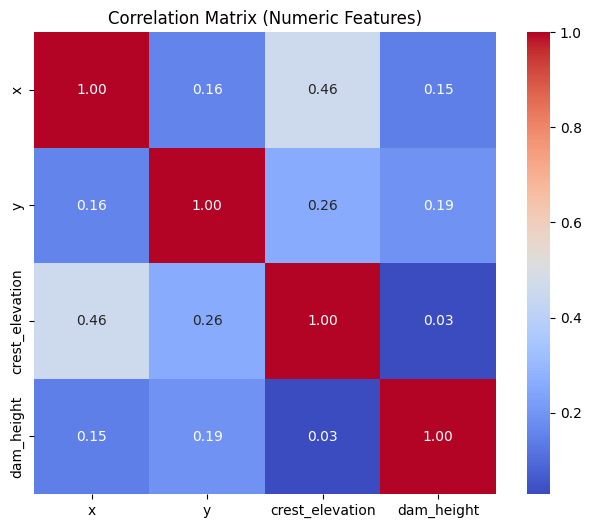

In [44]:
# Plot correlation matrix for all numeric features (including dam_height)
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()